<a href="https://colab.research.google.com/github/secret6767/Data-Mining-Phase-3/blob/main/Phase_3_Model_Training_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('GenomesUpdated (CSV).csv')

print(df.head())

   GENDER BLOOD TEST RESULT  GENES IN MOTHER'S SIDE  INHERITED FROM FATHER  \
0    Male            Normal                       1                      0   
1    Male            Normal                       1                      1   
2    Male      Inconclusive                       1                      0   
3    Male            Normal                       1                      0   
4  Female            Normal                       1                      0   

   MATERNAL GENE  PATERNAL GENE  HEART RATE  RESPIRATORY RATE  BIRTH ASPHYXIA  \
0              1              0           0                 0               0   
1              0              0           1                 0               0   
2              1              0           0                 1               0   
3              1              1           1                 1               0   
4              1              0           0                 0               0   

   H/O SERIOUS MATERNAL ILLNESS  H/O XRAY RA

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['GENDER'] = le.fit_transform(df['GENDER'])
print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
df['GENETIC DISORDER'] = le.fit_transform(df['GENETIC DISORDER'])
print("Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

size_mapping = {'Singular': 0, 'Multiple': 1}
df['BIRTH DEFECTS'] = df['BIRTH DEFECTS'].map(size_mapping)
size_mapping = {'Inconclusive': 0, 'Normal': 0, 'Slightly abnormal':1, 'Abnormal': 2}
df['BLOOD TEST RESULT'] = df['BLOOD TEST RESULT'].map(size_mapping)

print("\n", df.head())

Mapping: {'Ambiguous': np.int64(0), 'Female': np.int64(1), 'Male': np.int64(2)}
Mapping: {'Mitochondrial genetic inheritance disorders': np.int64(0), 'Multifactorial genetic inheritance disorders': np.int64(1), 'Single-gene inheritance diseases': np.int64(2)}

    GENDER  BLOOD TEST RESULT  GENES IN MOTHER'S SIDE  INHERITED FROM FATHER  \
0       2                  0                       1                      0   
1       2                  0                       1                      1   
2       2                  0                       1                      0   
3       2                  0                       1                      0   
4       1                  0                       1                      0   

   MATERNAL GENE  PATERNAL GENE  HEART RATE  RESPIRATORY RATE  BIRTH ASPHYXIA  \
0              1              0           0                 0               0   
1              0              0           1                 0               0   
2              1    

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay,  precision_recall_curve
import matplotlib.pyplot as plt

features = ['GENDER','BLOOD TEST RESULT','GENES IN MOTHER\'S SIDE','INHERITED FROM FATHER',
            'MATERNAL GENE', 'PATERNAL GENE','HEART RATE', 'RESPIRATORY RATE', 'BIRTH ASPHYXIA',
            'H/O SERIOUS MATERNAL ILLNESS','H/O XRAY RADIATION EXPOSURE','H/O SUBSTANCE ABUSE',
            'H/O A0MALIES IN PREVIOUS PREGNANCIES','BIRTH DEFECTS','GENETIC DISORDER']

X = df[features]
y = df['DISORDER SUBCLASS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

# Model: Support Vector Machines
model = SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.536756557074252
Precision: 0.3636089932958942
Recall: 0.536756557074252
F1 Score: 0.42687156922604136


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


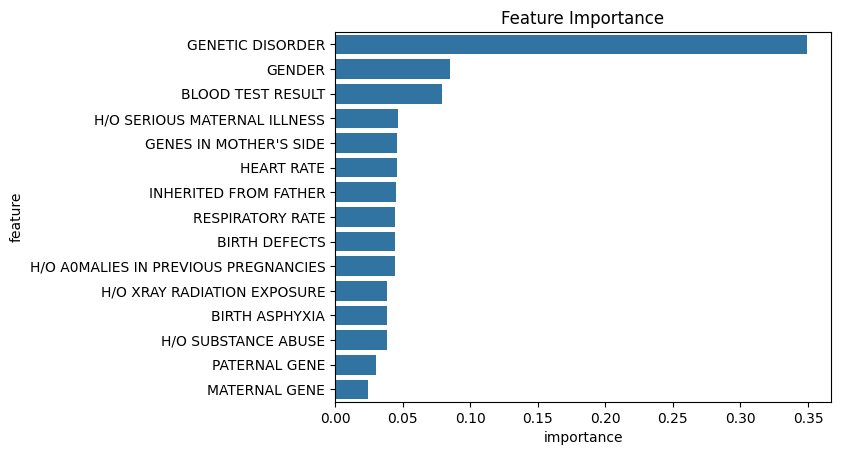

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns

features = ['GENDER','BLOOD TEST RESULT','GENES IN MOTHER\'S SIDE','INHERITED FROM FATHER',
            'MATERNAL GENE', 'PATERNAL GENE','HEART RATE', 'RESPIRATORY RATE', 'BIRTH ASPHYXIA',
            'H/O SERIOUS MATERNAL ILLNESS','H/O XRAY RADIATION EXPOSURE','H/O SUBSTANCE ABUSE',
            'H/O A0MALIES IN PREVIOUS PREGNANCIES','BIRTH DEFECTS','GENETIC DISORDER']

X = df[features]
y = df['DISORDER SUBCLASS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

# Model: Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

importances = rf_classifier.feature_importances_
features = X.columns

# Create DataFrame
feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Plot
sns.barplot(
    x="importance",
    y="feature",
    data=feat_imp
)

plt.title("Feature Importance")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report, precision_recall_curve
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

features = ['GENDER','BLOOD TEST RESULT','GENES IN MOTHER\'S SIDE','INHERITED FROM FATHER',
            'MATERNAL GENE', 'PATERNAL GENE','HEART RATE', 'RESPIRATORY RATE', 'BIRTH ASPHYXIA',
            'H/O SERIOUS MATERNAL ILLNESS','H/O XRAY RADIATION EXPOSURE','H/O SUBSTANCE ABUSE',
            'H/O A0MALIES IN PREVIOUS PREGNANCIES','BIRTH DEFECTS','GENETIC DISORDER']

X = df[features]
y = df['DISORDER SUBCLASS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

# Model: Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

In [ ]:
# STEP 4 — HYPERPARAMETER TUNING

import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib

df = pd.read_csv("GenomesUpdated.csv")

target = "GENETIC DISORDER"
df = df.dropna(subset=[target])

encoders = {}
for col in df.columns:
    if df[col].dtype == "object":
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)

param_dist = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, pred)
precision = precision_score(y_test, pred, average="weighted", zero_division=0)
recall = recall_score(y_test, pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, pred, average="weighted", zero_division=0)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred, zero_division=0))

Accuracy: 0.9878116343490305
Precision: 0.9880739866315624
Recall: 0.9878116343490305
F1 Score: 0.9875792943086165

Confusion Matrix:
 [[1808    0    0]
 [   0  361   42]
 [   0    2 1397]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1808
           1       0.99      0.90      0.94       403
           2       0.97      1.00      0.98      1399

    accuracy                           0.99      3610
   macro avg       0.99      0.96      0.98      3610
weighted avg       0.99      0.99      0.99      3610

